# Exploratory Data Analysis (EDA) on Airbnb NYC Dataset

## Introduction
Exploratory Data Analysis (EDA) helps us understand the structure, patterns, and insights from a dataset.

In this project, we analyze the Airbnb NYC dataset to explore pricing patterns, room types, neighborhood distribution, and availability of listings.

## Importing Required Libraries
We first import the libraries needed for data analysis and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset
The dataset is loaded using pandas and the first few rows are displayed.

In [5]:
df = pd.read_csv("AB_NYC_2019.csv.zip")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Dataset Overview
We examine the number of rows, columns, and data types in the dataset.

In [6]:
df.shape

(48895, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## Checking Missing Values
Missing values can affect analysis results, so we identify them first.

In [8]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Data Cleaning
We handle missing values to ensure accurate analysis.

In [9]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = df['last_review'].fillna("No Review")
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")

## Descriptive Statistics
We analyze basic statistical properties such as mean, median, minimum, and maximum values.

In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## Distribution of Room Types
We analyze how many listings belong to each room type.

In [11]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

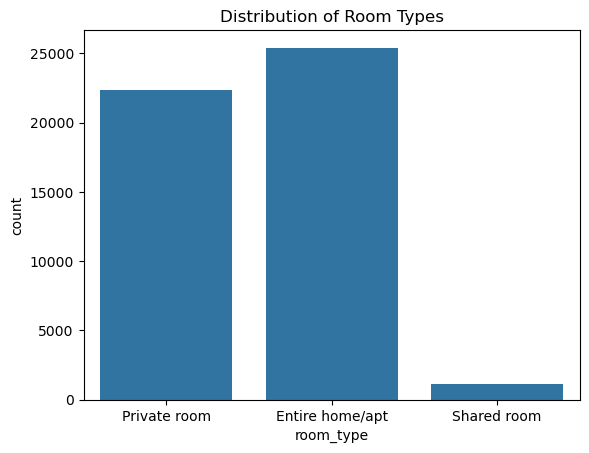

In [12]:
sns.countplot(x="room_type", data=df)
plt.title("Distribution of Room Types")
plt.show()

Observation:
This chart shows which type of accommodation (entire home, private room, shared room) is most common.

## Price Distribution
We examine how listing prices are distributed.

In [21]:
df_filtered = df[df["price"] <300]

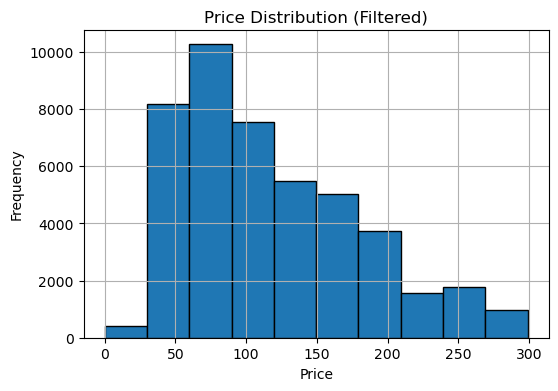

In [23]:
plt.figure(figsize=(6,4))
df_filtered["price"].hist(edgecolor='black')
plt.title("Price Distribution (Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Listings by Neighborhood Group
We analyze which borough of New York has the most Airbnb listings.

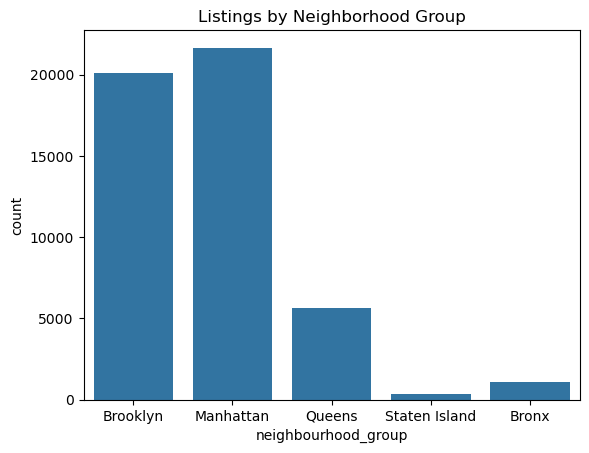

In [24]:
sns.countplot(x="neighbourhood_group", data=df)
plt.title("Listings by Neighborhood Group")
plt.show()

Observation:
This graph shows which borough has the highest number of Airbnb listings.

## Price by Room Type
We compare prices across different types of rooms.

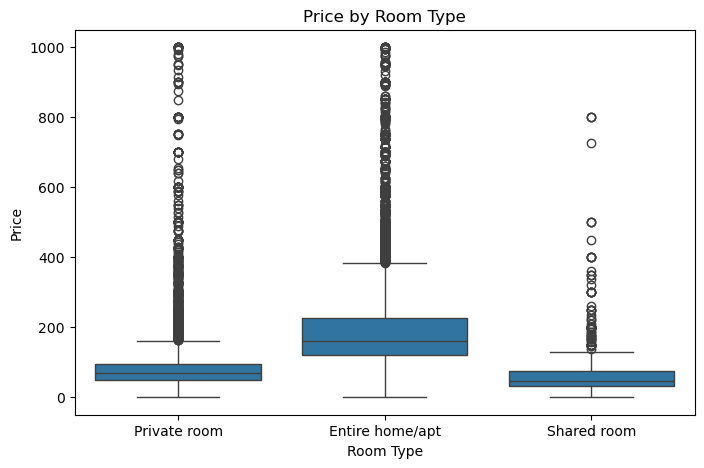

In [26]:
filtered_df = df[df["price"] < 1000]



plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=filtered_df)

plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

## Availability Analysis
We analyze how many days listings are available throughout the year.

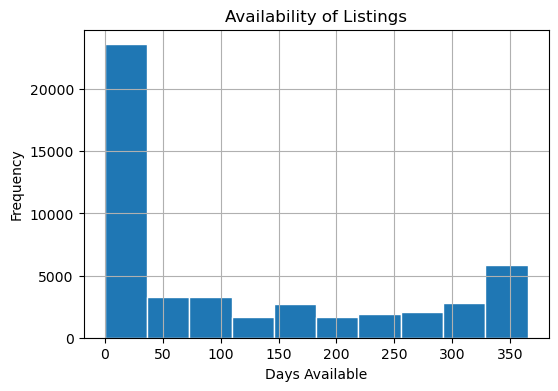

In [28]:
plt.figure(figsize=(6,4))
df["availability_365"].hist(edgecolor='white')
plt.title("Availability of Listings")
plt.xlabel("Days Available")
plt.ylabel("Frequency")
plt.show()

## Correlation Analysis
A heatmap helps identify relationships between numerical variables.

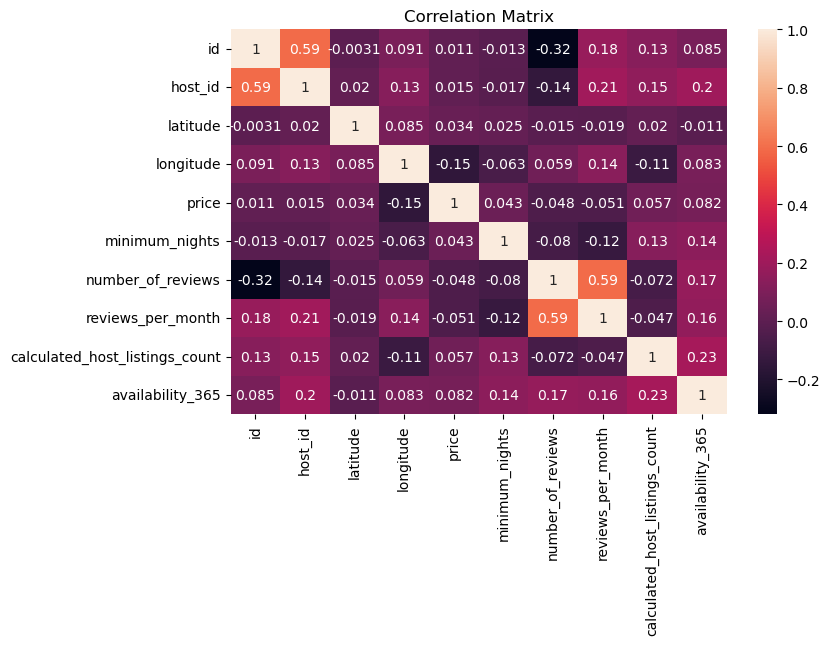

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Key Insights

1. Entire homes/apartments are the most common Airbnb listings.
2. Manhattan have significantly more listings than others.
3. Prices vary widely depending on room type and location.
4. Many listings are available throughout most of the year.

## Recommendations

• Property owners should price listings competitively based on room type.  
• High-demand neighborhoods can be targeted for investment.  
• Hosts can optimize availability to maximize bookings.